# Discovery evidence: time persistence, cross-program null, and PETAL localization

This executable walkthrough checks the three follow-up experiment
lines using only compact committed CSVs. It makes no network calls
and does not require raw DESI FITS files.

## tl;dr

- **E1-TEMPORAL — pass:** successive supported nights with
  1-to-7-day gaps have Pearson correlations of **0.33759 for
  BRIGHT** and **0.61162 for DARK**.
- **E2-COHERENCE-NULL — null:** the source-disjoint BRIGHT–DARK
  symmetric same-night correlation is **0.01003**, with
  Holm-adjusted **p = 0.4614**.
- **E3-PETAL — pass:** the mean incremental gain beyond the
  program-night model is **0.058141 km/s**, all **5/5 folds** are
  positive, split-half reproducibility is **r = 0.83133**, and none of
  99 controls reaches the real gain. The add-one p-value is
  **1/100 = 0.01**.

Persistence, a null cross-program test, and PETAL localization are
statistical patterns. None establishes an instrument mechanism or
hardware fault.


## Context & Methods

E1 asks whether a diagnostic night offset resembles the next
supported night when their gap is 1–7 days. E2 asks a stricter
question: after source
halves and within-program graphs are separated, do BRIGHT and DARK
share a same-calendar-night state? E3 asks whether PETAL-associated
structure adds held-out predictive value beyond program and night.

A Pearson correlation `r` ranges from -1 to 1. Values farther from
zero indicate a stronger linear pattern, but correlation alone does
not identify its cause. A *null* outcome means this declared test
did not support the proposed coherence; it does not prove that every
possible shared component is exactly zero.

### Key Assumptions

- The summary rows retain the preregistered grouping and correction
  methods from the experiment bundle.
- For E2, two directional correlations are combined with Fisher-z
  weights `n - 3`, then three pairwise p-values receive Holm's
  multiple-testing adjustment.
- For E3, folds are averaged equally and the empirical p-value uses
  the same add-one rule as the baseline notebook.


## Data

The temporal and coherence files hold the E1/E2 summary rows. E3
uses five held-out folds, 99 permutation controls, one split-half
reproducibility summary, and separate program/half PETAL offsets.
Every committed input is loaded below and its row count is shown.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def require(condition, message):
    if not bool(condition):
        raise RuntimeError(message)

ROOT = Path.cwd().resolve()
require((ROOT / "explanation" / "manifest.json").is_file(),
    "Run this notebook with the repository root as the working directory."
)

INPUTS = {
    "temporal": "experiments/2026-07-13_novel_signals/temporal_persistence.csv",
    "coherence": "experiments/2026-07-13_novel_signals/cross_program_coherence.csv",
    "petal_cv": "experiments/2026-07-13_novel_signals/petal_cv.csv",
    "petal_permutations": "experiments/2026-07-13_novel_signals/petal_permutations.csv",
    "petal_replication": "experiments/2026-07-13_novel_signals/petal_replication.csv",
    "petal_offsets": "experiments/2026-07-13_novel_signals/petal_independent_program_offsets.csv",
    "petal_program_summary": "experiments/2026-07-13_novel_signals/petal_independent_program_summary.csv",
}
datasets = {
    name: pd.read_csv(ROOT / relative_path)
    for name, relative_path in INPUTS.items()
}
pd.DataFrame(
    {
        "input": list(INPUTS),
        "rows": [len(datasets[name]) for name in INPUTS],
        "repository path": list(INPUTS.values()),
    }
)


,input,rows,repository path
0,temporal,4,experiments/2026-07-13_novel_signals/temporal_...
1,coherence,3,experiments/2026-07-13_novel_signals/cross_pro...
2,petal_cv,5,experiments/2026-07-13_novel_signals/petal_cv.csv
3,petal_permutations,99,experiments/2026-07-13_novel_signals/petal_per...
4,petal_replication,1,experiments/2026-07-13_novel_signals/petal_rep...
5,petal_offsets,40,experiments/2026-07-13_novel_signals/petal_ind...
6,petal_program_summary,2,experiments/2026-07-13_novel_signals/petal_ind...


## Results

### 1. E1 — temporal persistence within programs

BRIGHT and DARK meet the recorded E1 scope gates. BACKUP does not,
which is useful friction against an overbroad “every program has
memory” interpretation. Explicit checks protect the two claim-ledger
correlations and the full-pipeline maxT result.


In [2]:
temporal = datasets["temporal"].copy().set_index("SCOPE")
bright_r = temporal.loc["BRIGHT", "PEARSON_R_1_7D"]
dark_r = temporal.loc["DARK", "PEARSON_R_1_7D"]
bright_maxt_p = temporal.loc["BRIGHT", "FULL_PIPELINE_P_MAXT"]
dark_maxt_p = temporal.loc["DARK", "FULL_PIPELINE_P_MAXT"]

require(math.isclose(bright_r, 0.33759141739964144, abs_tol=1e-12), "E1 BRIGHT correlation changed")
require(math.isclose(dark_r, 0.6116203576747858, abs_tol=1e-12), "E1 DARK correlation changed")
require(math.isclose(bright_maxt_p, 1 / 101, abs_tol=1e-15), "E1 BRIGHT maxT p-value changed")
require(math.isclose(dark_maxt_p, 1 / 101, abs_tol=1e-15), "E1 DARK maxT p-value changed")
require(temporal.loc["BRIGHT", "SCOPE_PASS"], "E1 BRIGHT scope gate no longer passes")
require(temporal.loc["DARK", "SCOPE_PASS"], "E1 DARK scope gate no longer passes")
require(temporal.loc["BRIGHT", "E1_DECISION"] == "pass", "E1 decision changed")

pd.DataFrame(
    {
        "scope": ["BRIGHT", "DARK"],
        "Pearson r (successive, 1–7-day gaps)": [bright_r, dark_r],
        "full-pipeline maxT p": [bright_maxt_p, dark_maxt_p],
        "scope gate": [
            temporal.loc["BRIGHT", "SCOPE_PASS"],
            temporal.loc["DARK", "SCOPE_PASS"],
        ],
    }
).round(6)


,scope,"Pearson r (successive, 1–7-day gaps)",full-pipeline maxT p,scope gate
0,BRIGHT,0.337591,0.009901,True
1,DARK,0.611620,0.009901,True


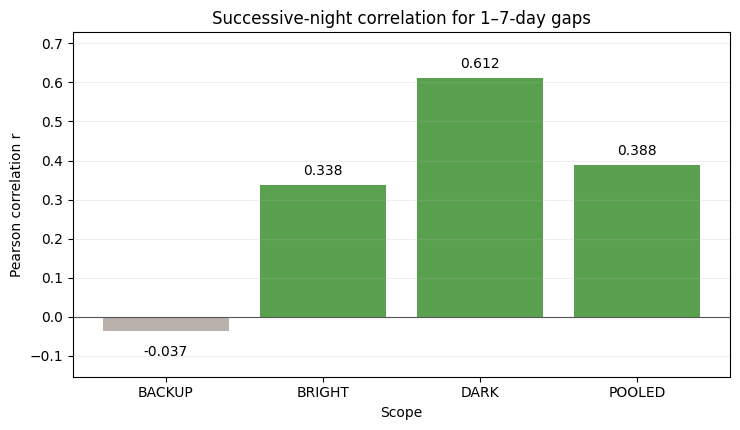

In [3]:
temporal_plot = temporal.loc[
    ["BACKUP", "BRIGHT", "DARK", "POOLED"], "PEARSON_R_1_7D"
]
temporal_pass = temporal.loc[
    ["BACKUP", "BRIGHT", "DARK", "POOLED"], "SCOPE_PASS"
].astype(bool)
colors = ["#59A14F" if passed else "#BAB0AC" for passed in temporal_pass]

fig, ax = plt.subplots(figsize=(7.5, 4.4))
bars = ax.bar(temporal_plot.index, temporal_plot.values, color=colors)
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set(
    title="Successive-night correlation for 1–7-day gaps",
    xlabel="Scope",
    ylabel="Pearson correlation r",
)
ax.margins(y=0.18)
ax.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, temporal_plot.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.018 if value >= 0 else -0.035),
        f"{value:.3f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )
fig.tight_layout()
plt.show()


### 2. E2 — the stricter BRIGHT–DARK coherence test is null

Each direction uses different source halves. The symmetric value is
recomputed by transforming both correlations to Fisher z, weighting
by `n - 3`, averaging, and transforming back. Holm's procedure then
adjusts the three recorded pairwise p-values without assuming the
primary pair was the only comparison inspected.


In [4]:
coherence = datasets["coherence"].copy()
primary = coherence.loc[
    (coherence["PROGRAM_P"] == "BRIGHT")
    & (coherence["PROGRAM_Q"] == "DARK")
].iloc[0]

r_ab = primary["R_P_A_Q_B"]
r_ba = primary["R_P_B_Q_A"]
n_ab = primary["N_P_A_Q_B"]
n_ba = primary["N_P_B_Q_A"]
symmetric_z = (
    (n_ab - 3) * np.arctanh(r_ab)
    + (n_ba - 3) * np.arctanh(r_ba)
) / ((n_ab - 3) + (n_ba - 3))
symmetric_r = np.tanh(symmetric_z)

def holm_adjust(p_values):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    ordered = values[order]
    scaled = (len(values) - np.arange(len(values))) * ordered
    monotone = np.maximum.accumulate(scaled)
    adjusted = np.empty_like(monotone)
    adjusted[order] = np.minimum(monotone, 1.0)
    return adjusted

holm_values = pd.Series(
    holm_adjust(coherence["BLOCK_NULL_P"]), index=coherence.index
)
primary_holm_p = holm_values.loc[primary.name]

require(math.isclose(symmetric_r, primary["SYMMETRIC_R0"], abs_tol=1e-14), "E2 symmetric correlation does not reproduce")
require(math.isclose(symmetric_r, 0.0100284072882246, abs_tol=1e-14), "E2 symmetric correlation changed")
require(math.isclose(primary_holm_p, primary["BLOCK_NULL_P_HOLM"], abs_tol=1e-12), "E2 Holm adjustment does not reproduce")
require(math.isclose(primary_holm_p, 0.4614, abs_tol=1e-12), "E2 Holm-adjusted p-value changed")
require(not primary["PASS"], "E2 outcome unexpectedly changed from null")

pd.DataFrame(
    {
        "quantity": [
            "BRIGHT A → DARK B r",
            "BRIGHT B → DARK A r",
            "recomputed symmetric r",
            "raw block-null p",
            "recomputed Holm p",
            "declared outcome",
        ],
        "value": [
            f"{r_ab:.6f} (n={int(n_ab)})",
            f"{r_ba:.6f} (n={int(n_ba)})",
            f"{symmetric_r:.6f}",
            f"{primary['BLOCK_NULL_P']:.4f}",
            f"{primary_holm_p:.4f}",
            "null / not passed",
        ],
    }
)


,quantity,value
0,BRIGHT A → DARK B r,0.046191 (n=123)
1,BRIGHT B → DARK A r,-0.026464 (n=122)
2,recomputed symmetric r,0.010028
3,raw block-null p,0.1538
4,recomputed Holm p,0.4614
5,declared outcome,null / not passed


### 3. E3 — incremental PETAL-associated structure

A PETAL is one of DESI's focal-plane sectors. The real statistic is
the held-out width reduction after adding PETAL-associated offsets
to the existing program-night model. A positive value is an
improvement; every recorded control here is below the real mean.


In [5]:
petal_cv = datasets["petal_cv"].copy()
petal_controls = datasets["petal_permutations"].copy()
petal_replication = datasets["petal_replication"].iloc[0]

fold_gains = petal_cv["INCREMENTAL_PETAL_GAIN_KMS"]
petal_mean_gain = fold_gains.mean()
positive_folds = int((fold_gains > 0).sum())
control_gains = petal_controls["MEAN_INCREMENTAL_GAIN_KMS"]
petal_exceedances = int((control_gains >= petal_mean_gain).sum())
petal_add_one_p = (petal_exceedances + 1) / (len(control_gains) + 1)
petal_replication_r = petal_replication["PEARSON_R"]

require(len(fold_gains) == 5, "Expected five E3 folds")
require(math.isclose(petal_mean_gain, 0.05814104905797004, abs_tol=1e-12), "E3 mean gain changed")
require(positive_folds == 5, "E3 no longer improves all five folds")
require(math.isclose(petal_replication_r, 0.8313286827891185, abs_tol=1e-12), "E3 split-half correlation changed")
require(len(control_gains) == 99, "Expected 99 E3 controls")
require(petal_exceedances == 0, "An E3 control now reaches the real result")
require(math.isclose(petal_add_one_p, 0.01, abs_tol=1e-15), "E3 empirical p-value changed")

pd.DataFrame(
    {
        "quantity": [
            "mean incremental gain",
            "positive folds",
            "source-half Pearson r",
            "controls >= real",
            "add-one empirical p",
        ],
        "recomputed value": [
            f"{petal_mean_gain:.6f} km/s",
            f"{positive_folds}/{len(fold_gains)}",
            f"{petal_replication_r:.5f}",
            f"{petal_exceedances} of {len(control_gains)}",
            f"{petal_add_one_p:.2f} (1/100)",
        ],
    }
)


,quantity,recomputed value
0,mean incremental gain,0.058141 km/s
1,positive folds,5/5
2,source-half Pearson r,0.83133
3,controls >= real,0 of 99
4,add-one empirical p,0.01 (1/100)


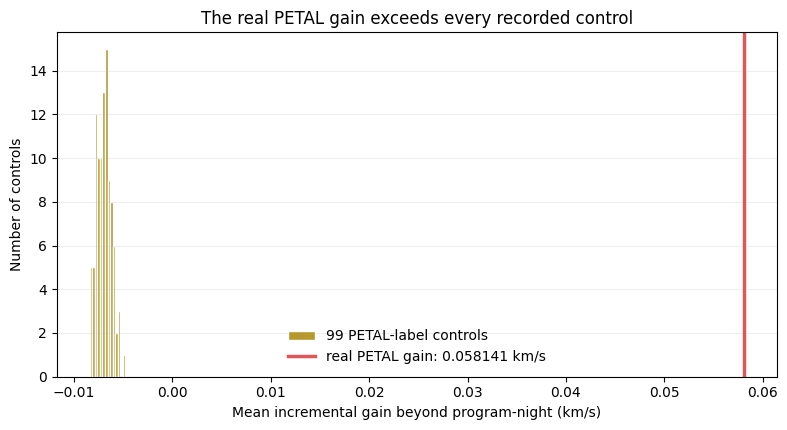

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.hist(
    control_gains,
    bins=14,
    color="#B6992D",
    edgecolor="white",
    label="99 PETAL-label controls",
)
ax.axvline(
    petal_mean_gain,
    color="#E15759",
    linewidth=2.5,
    label=f"real PETAL gain: {petal_mean_gain:.6f} km/s",
)
ax.set(
    title="The real PETAL gain exceeds every recorded control",
    xlabel="Mean incremental gain beyond program-night (km/s)",
    ylabel="Number of controls",
)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### 4. Disjoint program/half PETAL patterns

The final two inputs offer a second descriptive view. For each of
ten PETALs, compare median offsets from BRIGHT half A with DARK half
B, then reverse the halves. We recompute the correlations reported
in the compact summary. This is evidence that the spatial pattern
transfers; it still does not identify a hardware cause.


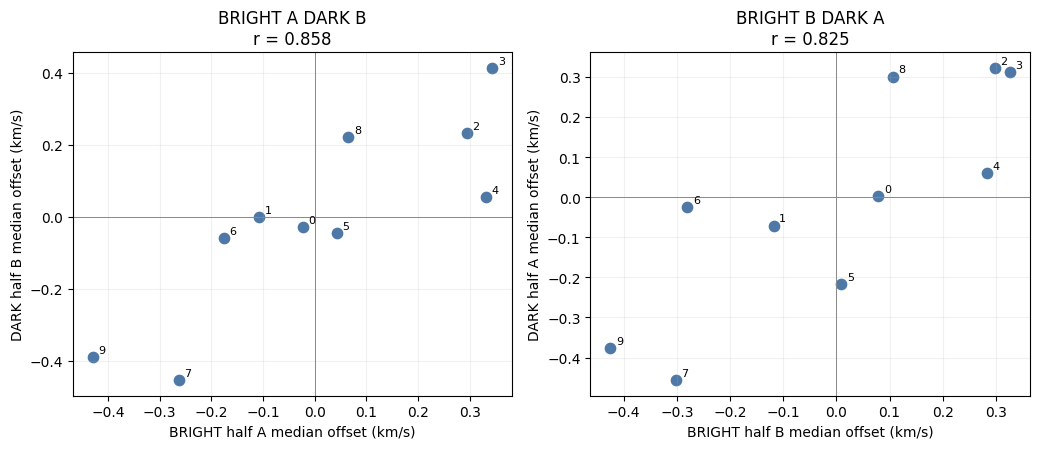

In [7]:
petal_offsets = datasets["petal_offsets"].copy()
petal_program_summary = datasets["petal_program_summary"].copy().set_index(
    "DIRECTION"
)
petal_pattern = petal_offsets.pivot(
    index="PETAL",
    columns=["PROGRAM", "HALF"],
    values="MEDIAN_OFFSET_KMS",
).sort_index()

directions = [
    ("BRIGHT_A_DARK_B", ("BRIGHT", "A"), ("DARK", "B")),
    ("BRIGHT_B_DARK_A", ("BRIGHT", "B"), ("DARK", "A")),
]
recomputed_directional_r = {}
for direction, x_key, y_key in directions:
    recomputed_r = np.corrcoef(
        petal_pattern[x_key], petal_pattern[y_key]
    )[0, 1]
    recomputed_directional_r[direction] = recomputed_r
    require(math.isclose(
        recomputed_r,
        petal_program_summary.loc[direction, "PEARSON_R"],
        abs_tol=1e-12,
    ), f"PETAL directional correlation changed for {direction}")
    require(
        int(petal_program_summary.loc[direction, "N_PETALS"]) == 10,
        f"Expected ten PETALs for {direction}",
    )

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, (direction, x_key, y_key) in zip(axes, directions):
    x = petal_pattern[x_key]
    y = petal_pattern[y_key]
    ax.scatter(x, y, s=55, color="#4E79A7")
    for petal, x_value, y_value in zip(petal_pattern.index, x, y):
        ax.annotate(
            str(petal),
            (x_value, y_value),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=8,
        )
    ax.axhline(0, color="#888888", linewidth=0.7)
    ax.axvline(0, color="#888888", linewidth=0.7)
    ax.set(
        title=f"{direction.replace('_', ' ')}\nr = {recomputed_directional_r[direction]:.3f}",
        xlabel=f"{x_key[0]} half {x_key[1]} median offset (km/s)",
        ylabel=f"{y_key[0]} half {y_key[1]} median offset (km/s)",
    )
    ax.grid(alpha=0.18)
fig.tight_layout()
plt.show()


## Takeaways

1. **E1 passes:** successive supported BRIGHT and DARK nights with
   1–7-day gaps show positive persistence under the recorded
   corrected controls, while BACKUP does not.
2. **E2 remains null:** the strict BRIGHT–DARK symmetric correlation
   is near zero and its Holm-adjusted p-value is 0.4614.
3. **E3 passes:** PETAL-associated structure adds a smaller but
   consistently positive held-out gain, reproduces across disjoint
   source halves, and exceeds all 99 controls.
4. These results localize and characterize residual structure. They
   do not show that PETAL hardware is faulty, prove instrument
   drift, or supply an official correction recipe.
